# Trend research без разрыва trend после test + block-CV

**Контекст.** В `market.ipynb` качество на разных положениях test-блока заметно плавает. Отдельно проверяем, помогает ли простая trend-компонента, если не рвать её сразу после test.

**Идея.** Добавляем к базовым макро-фичам три trend-фичи и сравниваем `baseline` против `baseline + trend` на 10 положениях block-CV.

**Спецификация.**
- 8 базовых фич из `market.ipynb`
- + 3 trend-фичи: `trend_3`, `trend_6`, `trend_10`
- Block-CV: 10 положений test-окна длиной 30% ряда
- Для каждой позиции считаем `baseline` и `baseline + trend`
- Выгружаем metrics / coefficients / SHAP в CSV

**Trend-логика**
- На train: считаем SMA `y[t-N:t]`. После test trend не обрываем: окно может заходить на test, потому что эти точки уже относятся к train после исключения test-блока из fit.
- На test: строим линейный trend `y ~ a + b * idx` по train-истории до начала test и экстраполируем его внутрь test.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('[warn] shap не установлен — SHAP-колонка будет пропущена')

DATA_IN  = Path('../data/quarterly_market_predictions.csv')
DATA_OUT = Path('data')
DATA_OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_IN).sort_values('quarter').reset_index(drop=True)

TARGET = 'market_log_level_q'
BASE_FEATURES = [
    'mortgage_avg_ticket_mln_rub_q',
    'subsidized_mortgage_2020_active_q',
    'rgbi_eoq',
    'usd_rub_min_q',
    'key_rate_max_q',
    'mortgage_total_volume_mln_rub_q',
    'mortgage_total_volume_mln_rub_q_log_return_q',
    'imoex_max_q',
]

def transform_feature_frame(feature_frame: pd.DataFrame) -> pd.DataFrame:
    """Ручные преобразования вместо scaler: держим фичи в сопоставимых масштабах."""
    X = feature_frame.copy()
    for col in X.columns:
        s = pd.to_numeric(X[col], errors='coerce')
        if col == 'mortgage_avg_ticket_mln_rub_q':
            X[col] = s / 2.0
        elif col == 'rgbi_eoq':
            X[col] = s / 100.0
        elif col == 'usd_rub_min_q':
            X[col] = s / 100.0
        elif col == 'key_rate_max_q':
            X[col] = s / 10.0
        elif col == 'mortgage_total_volume_mln_rub_q':
            X[col] = np.log(s.clip(lower=1e-9)) / 10.0
        elif col == 'imoex_max_q':
            X[col] = np.log(s.clip(lower=1e-9)) / 10.0
        elif col.endswith('_log_return_q'):
            X[col] = s * 5.0
        else:
            X[col] = s
    return X

print(f'Кварталов: {len(df)}  |  таргет: {TARGET}')
print(f'NaN в таргете: {df[TARGET].isna().sum()}')
print(f'Base features: {len(BASE_FEATURES)}')
print(f'Диапазон y: [{df[TARGET].min():.3f}, {df[TARGET].max():.3f}]')

c:\proga\gazprom_tex\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Кварталов: 45  |  таргет: market_log_level_q
NaN в таргете: 0
Base features: 8
Диапазон y: [11.932, 13.079]


In [2]:
df[BASE_FEATURES]

,mortgage_avg_ticket_mln_rub_q,subsidized_mortgage_2020_active_q,rgbi_eoq,usd_rub_min_q,key_rate_max_q,mortgage_total_volume_mln_rub_q,mortgage_total_volume_mln_rub_q_log_return_q,imoex_max_q
0,3.429635,0,112.87,56.2376,17.00,184.24,-0.975100,1838.18
1,3.923866,0,118.48,49.1777,14.00,237.08,0.252158,1721.80
2,3.776062,0,119.00,55.4756,11.50,283.62,0.179238,1733.17
3,3.479365,0,126.25,61.1535,11.00,438.40,0.435496,1868.07
4,3.549768,0,129.61,67.6076,11.00,406.20,-0.076286,1914.02
5,3.677739,0,132.78,63.7162,11.00,434.01,0.066222,1969.89
6,3.718551,0,134.56,62.9891,10.50,432.17,-0.004249,2053.75
7,3.873915,0,134.72,60.2730,10.00,553.35,0.247172,2247.02
8,3.977905,0,136.77,56.3779,10.00,439.28,-0.230854,2285.43
9,4.016461,0,137.82,55.8453,9.75,590.46,0.295765,2056.32


## 1. Генерация block-CV позиций

10 равномерно распределённых положений test-окна по всему ряду.


In [3]:
def generate_test_positions(n_quarters: int, test_frac: float = 0.3, n_positions: int = 10):
    """Равномерно распределяем старты test-блока длиной round(test_frac * n) по всему ряду."""
    test_size = int(round(n_quarters * test_frac))
    max_start = n_quarters - test_size
    starts = np.linspace(0, max_start, n_positions).round().astype(int)
    # Убираем повторы, если округление дало одинаковые старты
    seen, unique = set(), []
    for s in starts:
        if int(s) not in seen:
            seen.add(int(s)); unique.append(int(s))
    return [(s, s + test_size) for s in unique]

positions = generate_test_positions(len(df), test_frac=0.3, n_positions=10)
test_size = positions[0][1] - positions[0][0]
print(f'test_size = {test_size} кварталов')
print(f'{len(positions)} позиций:')
for i, (ts, te) in enumerate(positions):
    q_start = df.iloc[ts]['quarter']
    q_end   = df.iloc[te-1]['quarter']
    print(f'  pos {i}: idx [{ts:2d}, {te:2d})  ->  {q_start} .. {q_end}')


test_size = 14 кварталов
10 позиций:
  pos 0: idx [ 0, 14)  ->  2015Q1 .. 2018Q2
  pos 1: idx [ 3, 17)  ->  2015Q4 .. 2019Q1
  pos 2: idx [ 7, 21)  ->  2016Q4 .. 2020Q1
  pos 3: idx [10, 24)  ->  2017Q3 .. 2020Q4
  pos 4: idx [14, 28)  ->  2018Q3 .. 2021Q4
  pos 5: idx [17, 31)  ->  2019Q2 .. 2022Q3
  pos 6: idx [21, 35)  ->  2020Q2 .. 2023Q3
  pos 7: idx [24, 38)  ->  2021Q1 .. 2024Q2
  pos 8: idx [28, 42)  ->  2022Q1 .. 2025Q2
  pos 9: idx [31, 45)  ->  2022Q4 .. 2026Q1


## 2. Trend-фичи

**На train-точке `t`:** считаем SMA `y[t-N:t]`. Для post-test train точек окно может заходить на test, и это нормально: после исключения test из fit эти точки всё равно лежат в train, поэтому разрывать среднюю не нужно.

**На test-точке `t`:** строим линейный trend OLS `y ~ a + b * idx` по train-истории до начала test и используем `trend_N(t) = a + b * t`. Здесь fit никогда не видит точки из test.


In [4]:
def compute_trend_features(y: np.ndarray, test_start: int, test_end: int, Ns=(3, 6, 10)) -> pd.DataFrame:
    """Трендовые фичи для block-CV.
    - train точка t: обычная SMA последних N значений y (y[t-N:t]).
      На post-test train точках окно может заходить в test — это намеренно,
      чтобы trend не "срывался" на границе test/train.
    - test точка t: линейная экстраполяция от последних N train-точек ДО test_start.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    train_mask = np.ones(n, dtype=bool)
    train_mask[test_start:test_end] = False
    train_indices_all = np.where(train_mask)[0]
    train_mean = float(y[train_mask].mean())

    cols = {}
    for N in Ns:
        col = np.full(n, np.nan)

        # ---- test-точки: единый линейный fit на последних N pre-test train ----
        pre_test = train_indices_all[train_indices_all < test_start]
        if len(pre_test) >= 2:
            lookback = pre_test[-min(N, len(pre_test)):]
            slope, intercept = np.polyfit(lookback.astype(float), y[lookback], 1)
            for t in range(test_start, test_end):
                col[t] = intercept + slope * t
        else:
            # fallback: если pre-test train почти нет (test в самом начале)
            fill = train_mean if len(pre_test) == 0 else float(y[pre_test[0]])
            for t in range(test_start, test_end):
                col[t] = fill

        # ---- train-точки: обычная SMA y[t-N:t] (без пропуска test-гэпа),
        #      чтобы тренд не срывался на границе test/train ----
        for t in range(n):
            if not train_mask[t]:
                continue
            if t == 0:
                others = train_indices_all[train_indices_all != t]
                col[t] = float(y[others].mean()) if len(others) > 0 else train_mean
                continue
            lo = max(0, t - N)
            col[t] = float(y[lo:t].mean())

        cols[f'trend_{N}'] = col

    return pd.DataFrame(cols)

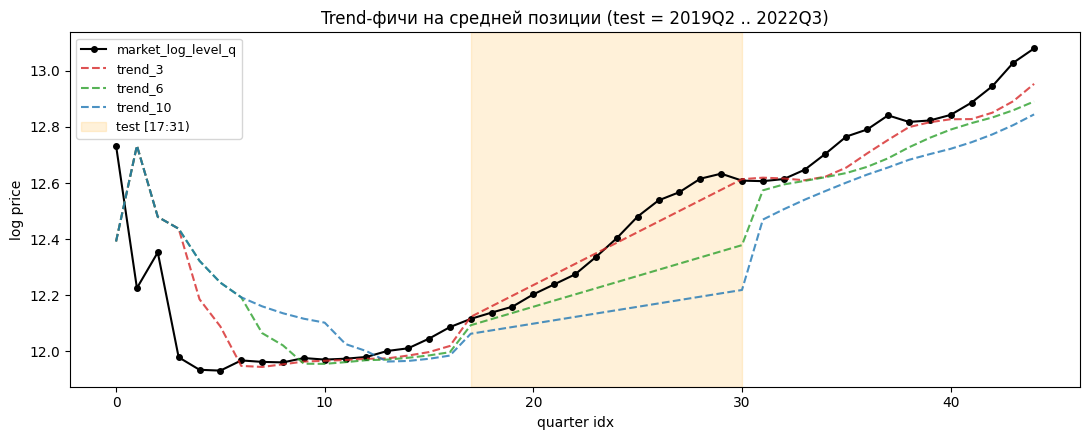


Пост-test train точки (SMA использует y[t-N:t], окно может захватывать test):
  t=31 (2022Q4):  trend_3=12.6191  trend_6=12.5740  trend_10=12.4698
  t=32 (2023Q1):  trend_3=12.6162  trend_6=12.5950  trend_10=12.5066
  t=33 (2023Q2):  trend_3=12.6098  trend_6=12.6076  trend_10=12.5405


In [5]:
# Sanity check: визуализация trend-фичей для одной позиции (test в середине)
mid_pos = positions[len(positions) // 2]
ts, te = mid_pos
y_full = df[TARGET].values
trend_df_mid = compute_trend_features(y_full, ts, te)

fig, ax = plt.subplots(figsize=(11, 4.5))
x_idx = np.arange(len(df))
ax.plot(x_idx, y_full, 'o-', color='black', label=TARGET, ms=4)
for col, color in zip(['trend_3', 'trend_6', 'trend_10'], ['#d62728', '#2ca02c', '#1f77b4']):
    ax.plot(x_idx, trend_df_mid[col].values, '--', color=color, label=col, alpha=0.8)
ax.axvspan(ts, te - 1, color='orange', alpha=0.15, label=f'test [{ts}:{te})')
ax.set_xlabel('quarter idx'); ax.set_ylabel('log price')
ax.set_title(f'Trend-фичи на средней позиции (test = {df.iloc[ts]["quarter"]} .. {df.iloc[te-1]["quarter"]})')
ax.legend(fontsize=9, loc='best')
plt.tight_layout(); plt.show()

# Проверка: на train-точках сразу после test фича должна плавно продолжать тренд
after_test_train = [t for t in range(te, len(df))][:3]
print(f'\nПост-test train точки (SMA использует y[t-N:t], окно может захватывать test):')
for t in after_test_train:
    print(f'  t={t} ({df.iloc[t]["quarter"]}):  '
          f'trend_3={trend_df_mid.iloc[t]["trend_3"]:.4f}  '
          f'trend_6={trend_df_mid.iloc[t]["trend_6"]:.4f}  '
          f'trend_10={trend_df_mid.iloc[t]["trend_10"]:.4f}')

## 3. Обучение Ridge + метрики + SHAP

Для каждой позиции считаем две модели и сохраняем metrics-таблицу, коэффициенты и агрегированные SHAP-важности.


In [6]:
def fit_and_evaluate(X_tr, y_tr, X_te, y_te, feature_names, model_tag, pos_idx, test_start, test_end):
    # Обучаемся без scaler, но на заранее приведённых к сопоставимому масштабу фичах,
    # чтобы коэффициенты и вклад trend-фич оставались интерпретируемыми.
    model = RidgeCV(alphas=np.logspace(-3, 3, 25), fit_intercept=True).fit(X_tr, y_tr)
    # model = RidgeCV(alphas=1, fit_intercept=True).fit(X_tr, y_tr)
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    metrics = {
        'position':   pos_idx,
        'test_start': test_start,
        'test_end':   test_end,
        'model':      model_tag,
        'n_features': len(feature_names),
        'alpha':      float(model.alpha_),
        'R2_train':   float(r2_score(y_tr, pred_tr)),
        'R2_test':    float(r2_score(y_te, pred_te)),
        'MAE_test':   float(mean_absolute_error(y_te, pred_te)),
        'RMSE_test':  float(np.sqrt(mean_squared_error(y_te, pred_te))),
    }

    # Коэффициенты на исходных именах фич, но уже после ручных преобразований.
    coefs = [{'position': pos_idx, 'model': model_tag,
              'feature': '__intercept__', 'coefficient': float(model.intercept_)}]
    for name, c in zip(feature_names, model.coef_):
        coefs.append({'position': pos_idx, 'model': model_tag, 'feature': name, 'coefficient': float(c)})

    # SHAP (если пакет доступен)
    shap_rows = []
    if HAS_SHAP:
        try:
            explainer = shap.LinearExplainer(model, X_tr, feature_names=feature_names)
            shap_vals = explainer.shap_values(X_tr)
            mean_abs = np.abs(shap_vals).mean(axis=0)
            shap_rows = [{'position': pos_idx, 'model': model_tag,
                          'feature': name, 'mean_abs_shap': float(v)}
                         for name, v in zip(feature_names, mean_abs)]
        except Exception as e:
            print(f'  [SHAP fail] pos={pos_idx} model={model_tag}: {e}')

    return metrics, coefs, shap_rows

## 4. Основной цикл: 10 позиций x 2 модели


In [7]:
y_full = df[TARGET].values
X_base_full = transform_feature_frame(df[BASE_FEATURES]).fillna(0.0).to_numpy()

all_metrics, all_coefs, all_shap = [], [], []

for pos_idx, (ts, te) in enumerate(positions):
    train_mask = np.ones(len(df), dtype=bool)
    train_mask[ts:te] = False
    y_tr = y_full[train_mask]
    y_te = y_full[~train_mask]

    # 1) baseline (8 фичей)
    Xb_tr = X_base_full[train_mask]
    Xb_te = X_base_full[~train_mask]
    m, c, s = fit_and_evaluate(Xb_tr, y_tr, Xb_te, y_te, BASE_FEATURES,
                               'baseline', pos_idx, ts, te)
    all_metrics.append(m); all_coefs.extend(c); all_shap.extend(s)

    # 2) baseline + trend (11 фичей)
    trend_df = compute_trend_features(y_full, ts, te, Ns=(3, 6, 10))
    X_wt_full = np.hstack([X_base_full, trend_df.to_numpy()])
    feat_wt = BASE_FEATURES + ['trend_3', 'trend_6', 'trend_10']
    Xwt_tr = X_wt_full[train_mask]
    Xwt_te = X_wt_full[~train_mask]
    m, c, s = fit_and_evaluate(Xwt_tr, y_tr, Xwt_te, y_te, feat_wt,
                               'baseline_plus_trend', pos_idx, ts, te)
    all_metrics.append(m); all_coefs.extend(c); all_shap.extend(s)

metrics_df = pd.DataFrame(all_metrics)
coefs_df   = pd.DataFrame(all_coefs)
shap_df    = pd.DataFrame(all_shap)

print(f'metrics rows:      {len(metrics_df)}')
print(f'coefficients rows: {len(coefs_df)}')
print(f'SHAP rows:         {len(shap_df)}')
metrics_df.round(3)

metrics rows:      20
coefficients rows: 210
SHAP rows:         190


,position,test_start,test_end,model,n_features,alpha,R2_train,R2_test,MAE_test,RMSE_test
0,0,0,14,baseline,8,0.018,0.969,-0.801,0.165,0.292
1,0,0,14,baseline_plus_trend,11,0.001,0.995,-5.021,0.507,0.534
2,1,3,17,baseline,8,0.018,0.874,-36.661,0.240,0.244
3,1,3,17,baseline_plus_trend,11,1.778,0.891,-93.293,0.313,0.386
4,2,7,21,baseline,8,1.778,0.825,-5.075,0.193,0.197
5,2,7,21,baseline_plus_trend,11,1.000,0.877,-4.184,0.149,0.182
6,3,10,24,baseline,8,0.032,0.890,-0.087,0.094,0.121
7,3,10,24,baseline_plus_trend,11,1.000,0.908,-1.098,0.131,0.168
8,4,14,28,baseline,8,0.018,0.937,-0.833,0.203,0.238
9,4,14,28,baseline_plus_trend,11,1.778,0.927,0.334,0.118,0.144


In [8]:
metrics_df.to_csv(DATA_OUT / 'metrics_by_position.csv', index=False)
coefs_df.to_csv  (DATA_OUT / 'coefficients_by_position.csv', index=False)
shap_path = DATA_OUT / 'shap_by_position.csv'
if len(shap_df) > 0:
    shap_df.to_csv(shap_path, index=False)
elif shap_path.exists():
    shap_path.unlink()
    print('[info] SHAP недоступен: удалили stale shap_by_position.csv')
else:
    print('[info] SHAP недоступен: shap_by_position.csv не создаём')
print('Saved:')
for p in sorted(DATA_OUT.glob('*.csv')):
    print(f'  {p} ({p.stat().st_size} B)')

Saved:
  data\coefficients_by_position.csv (12453 B)
  data\metrics_by_position.csv (2464 B)
  data\shap_by_position.csv (11509 B)


## 5. Сравнение: baseline vs baseline + trend


In [9]:
summary = (metrics_df
           .groupby('model')[['R2_train', 'R2_test', 'MAE_test', 'RMSE_test']]
           .agg(['mean', 'median', 'std'])
           .round(3))
summary

R2_train               R2_test                MAE_test  \
                        mean median    std    mean median     std     mean   
model                                                                        
baseline               0.909  0.924  0.049  -7.132 -3.555  10.949    0.221   
baseline_plus_trend    0.918  0.913  0.033 -16.715 -2.522  32.677    0.271   

                                  RMSE_test                
                    median    std      mean median    std  
model                                                      
baseline              0.21  0.070     0.267  0.247  0.084  
baseline_plus_trend   0.14  0.285     0.308  0.175  0.303

C:\Users\egort\AppData\Local\Temp\ipykernel_21292\3812878267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metrics_df, x='model', y='R2_test', ax=axes[0], palette='Set2')
C:\Users\egort\AppData\Local\Temp\ipykernel_21292\3812878267.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metrics_df, x='model', y='MAE_test', ax=axes[1], palette='Set2')


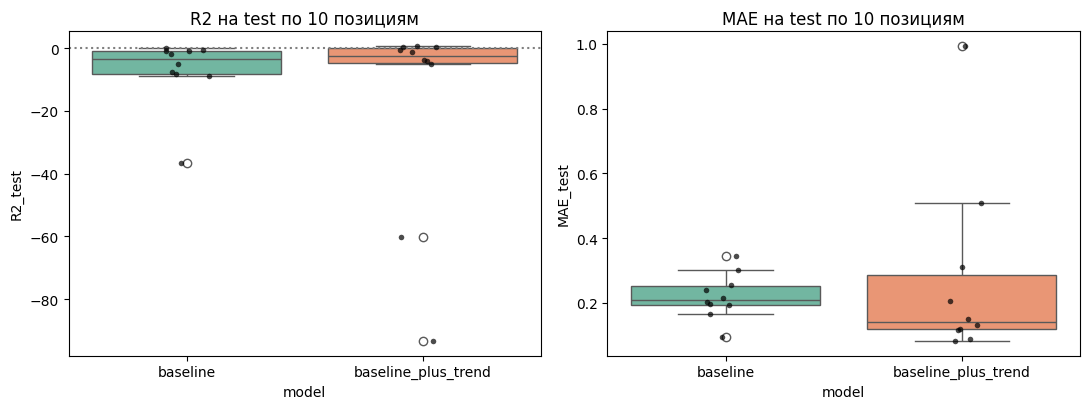

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.boxplot(data=metrics_df, x='model', y='R2_test', ax=axes[0], palette='Set2')
sns.stripplot(data=metrics_df, x='model', y='R2_test', ax=axes[0], color='black', size=4, alpha=0.7)
axes[0].set_title('R2 на test по 10 позициям'); axes[0].axhline(0, ls=':', color='grey')

sns.boxplot(data=metrics_df, x='model', y='MAE_test', ax=axes[1], palette='Set2')
sns.stripplot(data=metrics_df, x='model', y='MAE_test', ax=axes[1], color='black', size=4, alpha=0.7)
axes[1].set_title('MAE на test по 10 позициям')
plt.tight_layout(); plt.show()


In [11]:
# Сравнение по каждой позиции: какая модель лучше
wide = metrics_df.pivot(index='position', columns='model', values='R2_test')
wide['delta_R2'] = wide['baseline_plus_trend'] - wide['baseline']
wide['test_period'] = [f'{df.iloc[ts]["quarter"]}..{df.iloc[te-1]["quarter"]}'
                       for ts, te in positions[:len(wide)]]
wide = wide[['test_period', 'baseline', 'baseline_plus_trend', 'delta_R2']].round(3)
wide


model,test_period,baseline,baseline_plus_trend,delta_R2
position,,,,
0,2015Q1..2018Q2,-0.801,-5.021,-4.219
1,2015Q4..2019Q1,-36.661,-93.293,-56.632
2,2016Q4..2020Q1,-5.075,-4.184,0.891
3,2017Q3..2020Q4,-0.087,-1.098,-1.011
4,2018Q3..2021Q4,-0.833,0.334,1.167
5,2019Q2..2022Q3,-0.665,0.640,1.305
6,2020Q2..2023Q3,-2.034,0.469,2.504
7,2021Q1..2024Q2,-9.047,-0.724,8.323
8,2022Q1..2025Q2,-7.719,-3.947,3.772


In [12]:
# Средние коэффициенты trend-фичей по 10 позициям
trend_coefs = (coefs_df[(coefs_df.model == 'baseline_plus_trend') &
                         (coefs_df.feature.str.startswith('trend_'))]
               .groupby('feature')['coefficient']
               .agg(['mean', 'std'])
               .round(4))
print('Коэффициенты trend-фичей (без стандартизации):')
print(trend_coefs)

if {'model', 'feature', 'mean_abs_shap'}.issubset(shap_df.columns):
    trend_shap = (shap_df[(shap_df.model == 'baseline_plus_trend') &
                           (shap_df.feature.str.startswith('trend_'))]
                  .groupby('feature')['mean_abs_shap']
                  .agg(['mean', 'std'])
                  .round(4))
    print('\nSHAP trend-фичей:')
    print(trend_shap)
else:
    print('\nSHAP trend-фичей: пакет shap не установлен, колонка пропущена.')


Коэффициенты trend-фичей (без стандартизации):
            mean     std
feature                 
trend_10  0.0735  0.4898
trend_3   0.3171  0.3393
trend_6  -0.0194  0.3337

SHAP trend-фичей:
            mean     std
feature                 
trend_10  0.0596  0.0816
trend_3   0.0785  0.0785
trend_6   0.0504  0.0715


## Выводы

Смотрим на три вещи:

1. **Средний R2_test по 10 позициям** -- улучшает ли trend качество в среднем?
2. **Стабильность (std)** -- уменьшается ли разброс между позициями?
3. **Коэффициенты и SHAP trend-фичей** -- модель действительно на них опирается или нет?

Ключевой тест: если `delta_R2 > 0` на большинстве позиций, особенно ближе к концу ряда (2022+), то trend добавляет полезный сигнал. Если улучшение есть только в "лёгких" позициях, а на хвосте ряда trend не помогает, то structural break по-прежнему остаётся основной проблемой.

CSV в `trend_research/data/` сохраняются для последующего анализа.
